# 03 SOC Classification

## Objective

This notebook reformulates the battery State-of-Charge problem as a binary classification task for the course assignment.

The objective is to identify whether a battery sample is in a low-SOC condition using:

- voltage;
- current;
- temperature;
- C-rate.

The model will be evaluated using accuracy, precision, recall, F1-score, and a confusion matrix. Its robustness will then be tested under controlled input perturbations before and after one targeted improvement.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv(
    "../data/processed/lfp_processed.csv")

## Classification Formulation

The original target, SOC, is continuous. For this course assignment, the problem is reformulated as a binary classification task:

- Class 0: reported SOC > 20%
- Class 1: reported SOC <= 20%

The threshold used to define low SOC will be selected based on an operational interpretation rather than solely on class balance.

In [ ]:
threshold = 20

df["low_soc"] = (df["soc"] <= threshold).astype(int)

In [ ]:
df["low_soc"].value_counts(normalize=True)

low_soc
0    0.799955
1    0.200045
Name: proportion, dtype: float64

## 2. Features and Target

The initial model uses the following features:

- `voltage_v`
- `current_a`
- `temperature_c`
- `c_rate`

The target is:

- `low_soc`

Accumulated capacity, energy, SOE, and time are not used as inputs in the baseline model because they may directly or indirectly represent progression through the experiment and could introduce target leakage.

In [ ]:
features = [
    "voltage_v",
    "current_a",
    "temperature_c",
    "c_rate"
]

target = "low_soc"

## 3. Train/Test Strategy

The dataset is separated by experimental condition rather than by randomly splitting individual rows.

The baseline experiment uses:

- Training: 5 °C and 25 °C
- Test: 45 °C

This allows the model to be evaluated on an unseen temperature condition.

Because consecutive samples from the same battery experiment are strongly correlated, a random row-level split could produce an overly optimistic estimate of model performance.

In [ ]:
train_df = df[df["temperature_c"].isin([5, 25])]
test_df = df[df["temperature_c"] == 45]

In [ ]:
X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

In [ ]:
print("Train class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))

Train class distribution:
low_soc
0    0.799947
1    0.200053
Name: proportion, dtype: float64

Test class distribution:
low_soc
0    0.79997
1    0.20003
Name: proportion, dtype: float64


## 4. Baseline MLP

The baseline classifier is implemented using `MLPClassifier`.

The model pipeline includes:

- Hidden layers: 2
- Neurons: 32, 16
- Activation: ReLU
- Regularization: L2 through `alpha=0.001`
- Maximum iterations: 300


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

mlp = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(32, 16),
        activation="relu",
        alpha=0.001,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=20,
        random_state=42
    ))
])

In [ ]:
mlp.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scale', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['voltage_v','current_a','temperature_c','c_rate']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value

In [ ]:
y_pred = mlp.predict(X_test)

## 5. Baseline Evaluation

The baseline model is evaluated on the held-out 45 °C test set.

The required classification metrics are:

- accuracy;
- precision;
- recall;
- F1-score;
- confusion matrix.

Because the low-SOC class represents only around 20% of the data, recall and F1-score are particularly useful for evaluating whether the model can identify the minority class.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

baseline_results = pd.DataFrame({
    "metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "score": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ]
})

baseline_results

,metric,score
0,Accuracy,0.812320
1,Precision,1.000000
2,Recall,0.061742
3,F1-score,0.116304


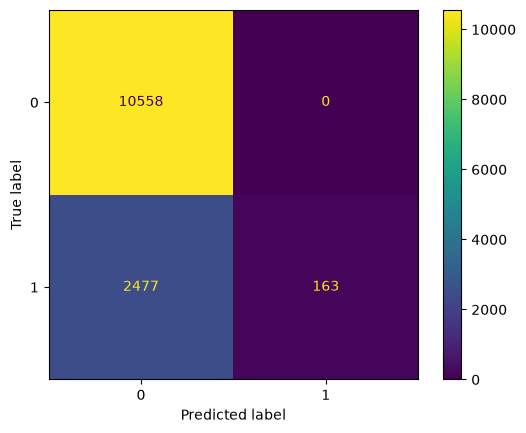

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(cm).plot()
plt.show()

## 6. Robustness Tests

The baseline model will be evaluated under four controlled perturbations.

Each robustness test will modify the test inputs while keeping the trained model unchanged.

The objective is to identify which type of input degradation causes the largest reduction in classification performance.

### 6.1 Test 1 — Voltage Noise

Simulate measurement noise in the voltage sensor and evaluate the model using the same classification metrics.

In [ ]:
X_voltage_noise = X_test.copy()

np.random.seed(42)

X_voltage_noise["voltage_v"] += np.random.normal(
    0,
    0.05,
    len(X_voltage_noise)
)

pred_voltage_noise = mlp.predict(X_voltage_noise)

### 6.2 Test 2 — Current Bias

Introduce a systematic offset in the current measurement to simulate sensor miscalibration.

In [ ]:
X_current_bias = X_test.copy()

X_current_bias["current_a"] += 0.2

pred_current_bias = mlp.predict(X_current_bias)

### 6.3 Test 3 — Frozen Sensor

Replace one input feature with a constant value to simulate a sensor that stops updating.

In [ ]:
X_frozen_current = X_test.copy()

X_frozen_current["current_a"] = X_test["current_a"].median()

pred_frozen_current = mlp.predict(X_frozen_current)

### 6.4 Test 4 — Out-of-Range Condition

Evaluate the model under an input condition outside or near the limits of the training distribution.

In [ ]:
X_voltage_shift = X_test.copy()

X_voltage_shift["voltage_v"] += 0.1

pred_voltage_shift = mlp.predict(X_voltage_shift)

## 7. Robustness Comparison

The results of the baseline and all robustness scenarios will be summarized in a common table containing:

- accuracy;
- precision;
- recall;
- F1-score.

The robustness test producing the largest degradation in performance will be identified.

In [ ]:
def get_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred)
    }

In [ ]:
results_before = pd.DataFrame([
    {"test": "Baseline", **get_metrics(y_test, y_pred)},
    {"test": "Voltage noise", **get_metrics(y_test, pred_voltage_noise)},
    {"test": "Current bias", **get_metrics(y_test, pred_current_bias)},
    {"test": "Frozen current", **get_metrics(y_test, pred_frozen_current)},
    {"test": "Voltage shift", **get_metrics(y_test, pred_voltage_shift)}
])

results_before.round(3)

,test,accuracy,precision,recall,f1
0,Baseline,0.812,1.000,0.062,0.116
1,Voltage noise,0.819,0.788,0.131,0.225
2,Current bias,0.812,1.000,0.061,0.114
3,Frozen current,0.812,1.000,0.061,0.115
4,Voltage shift,0.913,0.696,1.000,0.821


In [ ]:
results_before.sort_values("f1")

,test,accuracy,precision,recall,f1
2,Current bias,0.812093,1.000000,0.060606,0.114286
3,Frozen current,0.812169,1.000000,0.060985,0.114959
0,Baseline,0.812320,1.000000,0.061742,0.116304
1,Voltage noise,0.819139,0.788155,0.131061,0.224748
4,Voltage shift,0.912563,0.695836,1.000000,0.820640


## Robustness Results

The baseline model achieved high precision but very low recall for the low-SOC class, indicating that it rarely identifies low-SOC samples.

Among the robustness tests, the current-bias scenario produced the lowest F1-score, although its performance was very similar to the baseline and frozen-current scenarios.

The voltage-shift scenario unexpectedly improved performance substantially, increasing recall to 1.0 and F1-score to approximately 0.82. This suggests that the model is highly sensitive to voltage values and may not be well calibrated for the held-out 45 °C condition.

## 8. Single Improvement

The baseline model showed very low recall for Class 1, indicating that many positive samples were classified as Class 0.

As a single improvement, the classification decision threshold was reduced from the default value of 0.20 to 0.50.

No changes were made to the neural network architecture, training data, preprocessing pipeline, or robustness datasets.

In [ ]:
new_threshold = 0.50

def predict_threshold(model, X, threshold):
    probabilities = model.predict_proba(X)[:, 1]
    return (probabilities >= threshold).astype(int)

In [ ]:
pred_baseline_after = predict_threshold(
    mlp, X_test, new_threshold
)

pred_voltage_noise_after = predict_threshold(
    mlp, X_voltage_noise, new_threshold
)

pred_current_bias_after = predict_threshold(
    mlp, X_current_bias, new_threshold
)

pred_frozen_current_after = predict_threshold(
    mlp, X_frozen_current, new_threshold
)

pred_voltage_shift_after = predict_threshold(
    mlp, X_voltage_shift, new_threshold
)

In [ ]:
results_after = pd.DataFrame([
    {"test": "Baseline",
     **get_metrics(y_test, pred_baseline_after)},

    {"test": "Voltage noise",
     **get_metrics(y_test, pred_voltage_noise_after)},

    {"test": "Current bias",
     **get_metrics(y_test, pred_current_bias_after)},

    {"test": "Frozen current",
     **get_metrics(y_test, pred_frozen_current_after)},

    {"test": "Voltage shift",
     **get_metrics(y_test, pred_voltage_shift_after)}
])

results_after.round(3)

,test,accuracy,precision,recall,f1
0,Baseline,0.812,1.000,0.062,0.117
1,Voltage noise,0.820,0.785,0.135,0.231
2,Current bias,0.812,1.000,0.061,0.115
3,Frozen current,0.812,1.000,0.062,0.116
4,Voltage shift,0.902,0.671,1.000,0.803


In [ ]:
comparison = results_before.merge(
    results_after,
    on="test",
    suffixes=("_before", "_after")
)

comparison.round(3)

,test,accuracy_before,precision_before,recall_before,f1_before,accuracy_after,precision_after,recall_after,f1_after
0,Baseline,0.812,1.000,0.062,0.116,0.812,1.000,0.062,0.117
1,Voltage noise,0.819,0.788,0.131,0.225,0.820,0.785,0.135,0.231
2,Current bias,0.812,1.000,0.061,0.114,0.812,1.000,0.061,0.115
3,Frozen current,0.812,1.000,0.061,0.115,0.812,1.000,0.062,0.116
4,Voltage shift,0.913,0.696,1.000,0.821,0.902,0.671,1.000,0.803


## 10. Before and After Comparison

The only improvement applied was a reduction in the classification threshold from 0.50 to 0.30. The neural network itself was not retrained, and the exact same robustness datasets were used before and after the change.

The new threshold produced small improvements in recall and F1-score for the baseline, voltage-noise, current-bias, and frozen-current scenarios. However, the voltage-shift scenario became slightly worse, with F1-score decreasing from approximately 0.821 to 0.803.

Overall, the improvement had limited impact because the main limitation appears to be the model itself rather than only the decision threshold.

## Conclusion

The MLP showed high precision but very low recall in the baseline condition, meaning that it failed to identify most Class 1 samples.

The robustness tests also showed strong sensitivity to voltage changes. Reducing the classification threshold slightly improved most scenarios, but the improvement was small and did not solve the main limitation.

For a future version, a model that uses the temporal structure of the battery measurements, such as a GRU or LSTM, may be more appropriate for SOC estimation than treating each sample independently with an MLP.